+ Deep Learning Task (DLT): (e.g., industrial environmental monitoring) is a computing-intensive task that needs to be processed (i.e., inference or prediction) with a deep learning model, e.g., fully connecte network:
    + Industrial environmental monitoring
    + Product quality inspection
    + Factory dangerous behavior detection
    + Industrial dust detection 
    + ...

DLT in IIOT have stringent requirements for real-time performace. However, due to the large distance between the central cloud and users, it becomes challenging to fulfill the requirements for low latency in dadta transmission and communication.


+ Wireless sensors: $S = \{s_1, s_2, ..., s_N\}$ -> can be used to monitor the environment, collect data, and process data.

Each sensor has a task queue.
The data(task) arrival rate of sensor $s_i$ is $DA_i$. When the data arrival rate is too high, there may be a queue backlog. 

+ AP: supplies energy for sensor + receives and process the data from the sensor and returns the result to the sensor.

+ The **gain of wirless channel** between the AP and seonsor $s_i$ within each frame duration of $T$ is denoted by $g_i$ -> assumed to be static in per-frame

+ Every sensor deploys a **shallow** deep learning model with an inference accuracy of $A_1$.

+ The edge server deploys a full deep learning model for inference on sensor data with an inference accuracy of $A_2$, where $A_2 > A_1$ and both DNN1 and DNN2 are trained for inference only.

To prevent wireless signals from interfering with each other, each sensor takes turns communicating and harvesting energy from the AP. This method is called time-division multiplexing(TDM). Essentially, instead of multiple sensors trying to use the wireless channel at the same time, they are allocated different time slots. This ensures that each sensor can complete its tasks without its signal being garbled by another sensor's signal.

+ Sensors are usually unable to handle tasks with high accuracy requirements locally. <br>
A large number of tasks trasmitted to the edge server from sensors will icnrease the delay, which reduces system revenue, e.g., the CR (i.e., the amont of data processed per second, the unit is bit per second). Therefore, we need to determine which tasks need to be processed locally or offloaded to the edge server to increase system revenue.

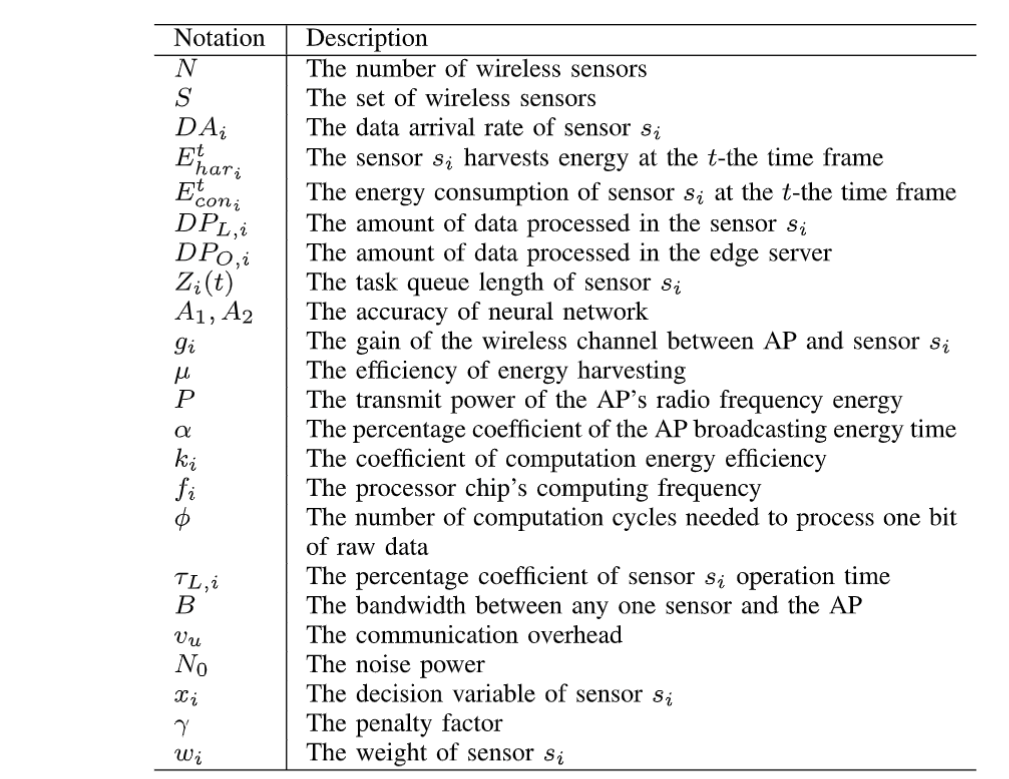

The senosr $s_i$ harvests energy at the $t$ th time frame is modeled as:

$$E_{\text{har}_i}^t = \mu Pg_i^t\alpha^tT$$

+ $\mu$ -> efficiency of energy harvesting which lies between 0 and 1
+ $P$ -> denotes the transmit power of the AP's radio frequency energy. 
+ $\alpha^tT$ -> denotes the time of broadcasting energy from AP to all sensors at the $t$ th time frame.
    + $\alpha$ -> percentage coefficient of the AP boradcasting energy with respect to duration $T$.

+ $k_if_i^3$ -> The power consumption of a sensor's processor
    + $k_i$ -> signifies the coefficient of computation energy efficiency
    + $f_i$ -> refers to the processor chip's computation frequency

The energy consumption of sensor $s_i$ during the $t$ th time frame is represented as:

##### Local computing

$$E_{\text{con}_i}^t = k_i^t(f_i^3)^t\tau_{L, i}^tT$$

+ $\tau_{L, i}^tT$ -> is the operation time of the sensor $s_i$ at the time $t$ th time frame.
    + $\tau_{L, i}$ is the percentage coefficient of the sensor $s_i$ operation time with respect to duration $T$.

To ensure the sensor $s_i$ normal operation, we also assueme that all the harvesting energy of teh sensor $s_i$ at the $t$ th time frame is used to process the data, then we have:
$$E_{\text{har}_i}^t = E_{\text{con}_i}^t$$

The sensor consumes energy all the time in the duration $T$, so the $\tau_{L, i}$ equals to 1, and then we're gonna have:

$$f_i^t = (\frac{\mu Pg_i^t\alpha^t}{k_i})^\frac{1}{3}$$

Which is the processor chip's computation frequency.

The amount of data (in bits) processed in the seonsor $s_i$ is modeled as:
$$DP_{L, i}^t = \frac{f_i^tT}{\phi}$$

Having the two equation above, we can say:
$$DP_{L, i}^t = \frac{(\frac{\mu Pg_i^t\alpha^t}{k_i})^\frac{1}{3}T}{\phi}$$

+ $\phi$ -> Thee number of computation cycles needed to process one bit of raw data

##### Edge Computing


The data that needs to be **transmitted** from the sensor $s_i$ to the edge server:

$$DP_{O, i}^t = \frac{B\tau_{O, i}^tT}{v_u} \log_2(1 + \frac{P_i^tg_i^t}{N_0})$$

+ $B$ -> transmission bandwidth between any one sensor and the AP.
+ $v_u$ -> communciation overhead 
+ $P_i^t$ -> transmit power
+ $\tau_{O, i}^tT$ -> transmit time
    + $\tau_{O, i}$ -> percentage coefficient of sensor $s_i$ transmit time with respect to duration $T$. $N_0$ represents the noise power (in watt). Moreover, $\sum_{i}^{N} \tau_{O,i}^t + \alpha^t \leq 1$